## Liquidity Measures and Trading Costs

Rong Wang, June 2026

In [1]:
# Packages 
import numpy as np
import pandas as pd
import os
import gc
import time
import datetime as dt
from dateutil.relativedelta import relativedelta
from pandas.tseries.offsets import *
from joblib import Parallel, delayed
from pathlib import Path
from tqdm import tqdm
import wrds
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data directory
datapath = Path('/work/rw196/data/')

# WRDS connection
conn = wrds.Connection(wrds_username='adamwang08')

Loading library list...
Done


In [2]:
# Sample period
startdate = '01/01/1960'
enddate   = '12/31/2025'

##### Notice the transition from CRSP SIZ/FIZ to CIZ Format. 

CRSP has migrated its U.S. Stock Database from the legacy SIZ/FIZ format to the new CIZ (CRSP Integrated Zip) format. The CIZ architecture is designed to consolidate information that previously resided in multiple files, improve consistency across CRSP products, provide richer security-level metadata, and simplify common research workflows by reducing the number of auxiliary merges required. As part of this transition, the legacy stock files (e.g., msf, dsf) are no longer the primary production datasets and are no longer updated after the December 2024 release. New CRSP releases are distributed through the CIZ framework and exposed in WRDS through tables such as msf_v2 and related security master datasets.es.

Because of this transition, several aspects of the conventional CRSP workflow must be modified. Detailed discussions of the SIZ-to-CIZ migration, variable mappings, and methodological differences can be found in the CRSP and WRDS documentation:

- [WRDS CRSP Data Changes Announcement](https://wrds-www.wharton.upenn.edu/pages/data-announcements/changes-to-crsp-data/)
- [CRSP US Stock & Indexes Database Guide: Flat File Format 2.0 (CIZ)](https://wrds-www.wharton.upenn.edu/documents/1996/CRSP_US_Stock__Indexes_Database_Guide_Flat_File_Format_2.0.pdf)
- [CRSP SIZ-to-CIZ Cross-Reference Guide](https://www.crsp.org/wp-content/uploads/guides/CRSP_Cross_Reference_Guide_1.0_to_2.0.pdf)

Monthly and daily stock data and common-stock identification:

The conventional approach uses the legacy CRSP monthly and daily stock files (msf, dsf), together with the corresponding security header table (msfhdr, dsfhdr), and delisting files (msedelist, dsedelist). In this project, I instead use the CIZ-based CRSP Version 2 tables—msf_v2, dsf_v2, stksecurityinfohdr, and stkdelists—which replace the legacy schema and continue to receive updates beyond December 2024. Under the CIZ framework, the legacy share-code classification is replaced by a richer security classification system. Consequently, common stocks are identified using a combination of security characteristics, including sharetype, securitytype, securitysubtype, usincflg, and issuertype, following the mappings recommended by CRSP and WRDS to replicate the traditional common-stock universe.

Under the CIZ framework, the legacy share-code classification is replaced by a richer security classification system. Consequently, common stocks are identified using a combination of security characteristics, including sharetype, securitytype, securitysubtype, usincflg, and issuertype, following the mappings recommended by CRSP and WRDS to replicate the traditional common-stock universe.

### Get CRSP Data from WRDS

#### Daily Stock File

Table dsf_v2, replacing the legacy table, dsf.

Load data in batches to avoid crashing the kernel. It takes ~ 30 mins.

In [3]:
# dfs = []
# for start in tqdm(range(1960, 2026, 10)):
#     end = min(start + 9, 2025)

#     df = conn.raw_sql(f"""
#         SELECT permno, dlycaldt, yyyymmdd, dlyret, dlyretx, dlyvol, shrout, dlyprc, dlycap,
#                dlyask, dlybid, dlyopen, dlyclose, dlyhigh, dlylow, dlynumtrd, dlycumfacpr, dlycumfacshr
#         FROM crsp.dsf_v2
#         WHERE dlycaldt BETWEEN '{start}-01-01' AND '{end}-12-31'
#           AND sharetype = 'NS'
#           AND securitytype = 'EQTY'
#           AND securitysubtype = 'COM'
#           AND usincflg = 'Y'
#           AND issuertype IN ('ACOR','CORP')
#     """, date_cols=['dlycaldt'])

#     dfs.append(df)
#     df.to_parquet(datapath / f"crsp/crsp_dsf_{start}_{end}.parquet", engine="pyarrow")

# # Append to a single DataFrame
# dsf = pd.concat(dfs, ignore_index=True)
# dsf.to_parquet(datapath / "crsp/crsp_dsf.parquet", engine="pyarrow")

100%|██████████| 7/7 [38:05<00:00, 326.44s/it]


In [3]:
%%time
# Load saved data
dsf = pd.read_parquet(datapath / 'crsp/crsp_dsf.parquet')

CPU times: user 18.5 s, sys: 8.55 s, total: 27 s
Wall time: 11.1 s


In [4]:
# Rename all columns
dsf.columns = ['permno', 'date', 'yyyymmdd', 'ret', 'retx', 'vol', 'shrout', 'prc', 'mktcap', 
                 'ask', 'bid', 'open', 'close', 'high', 'low', 'numtrd', 'cfacpr', 'cfacshr']
dsf

,permno,date,yyyymmdd,ret,retx,vol,shrout,prc,mktcap,ask,bid,open,close,high,low,numtrd,cfacpr,cfacshr
0,10006,1960-01-04,19600104,0.03866,0.03866,2300.0,1418,50.375,71431.75,<NA>,<NA>,49.625,50.375,50.5,49.5,NaN,6.0,6.0
1,10014,1960-01-04,19600104,0.055556,0.055556,2000.0,2183,4.75,10369.25,<NA>,<NA>,4.625,4.75,4.75,4.5,NaN,1.05,1.05
2,10022,1960-01-04,19600104,-0.018182,-0.018182,4800.0,1537,13.5,20749.5,<NA>,<NA>,13.75,13.5,13.875,13.5,NaN,1.0,1.0
3,10030,1960-01-04,19600104,0.0,0.0,500.0,1624,50.0,81200.0,<NA>,<NA>,50.5,50.0,50.5,49.75,NaN,2.0,2.0
4,10057,1960-01-04,19600104,0.011547,0.011547,200.0,500,54.75,27375.0,<NA>,<NA>,54.25,54.75,54.75,54.25,NaN,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74988089,93374,2025-12-31,20251231,-0.009831,-0.009831,466404.0,101900,61.44,6260736.0,61.44,61.41,61.99,61.44,62.385,61.315,NaN,1.0,1.0
74988090,93397,2025-12-31,20251231,0.01243,0.01243,132469.0,18037,12.625,227717.13,12.64,12.61,12.62,12.625,12.725,12.36,2013.0,1.0,1.0
74988091,93426,2025-12-31,20251231,-0.011046,-0.011046,273127.0,12256,38.5,471856.0,38.58,38.51,39.22,38.5,39.22,37.67,NaN,1.0,1.0
74988092,93429,2025-12-31,20251231,-0.013907,-0.013907,374859.0,104645,251.0,26265895.0,251.46,251.05,255.84,251.0,255.84,250.95,NaN,1.0,1.0


#### Stock delisting

Table stkdelists, replacing the legacy delisting tables, msedelist and dsedelist.

In [ ]:
# delist = conn.get_table(library='crsp', table='stkdelists')
# delist.to_parquet(datapath / 'crsp/crsp_delist.parquet', engine='pyarrow')

In [5]:
# Load saved data
delist = pd.read_parquet(datapath / 'crsp/crsp_delist.parquet')
delist

,permno,delistingdt,deldtprc,deldtprcflg,delactiontype,delstatustype,delreasontype,delpaymenttype,delpermno,delpermco,delret,delretmisstype,delnextdt,delnextprc,delnextprcflg,delamtdt,deldivamt,deldistype,deldlydt
0,10000,1987-06-11,0.21875,BA,GDR,VCL,INSC,PRCF,0,0,0.0,NA,1987-06-12,0.21875,DP,1987-06-12,0.0,NO,1987-06-12
1,10001,2017-08-03,13.1,TR,MER,FPAY,UNAV,CASH,0,0,0.0,NA,<NA>,<NA>,DA,2017-08-04,13.1,D1,2017-08-04
2,10002,2013-02-15,2.98,TR,MER,FPAY,UNAV,STK,35263,1658,0.010906,NA,<NA>,<NA>,DA,2013-02-19,3.0125,D1,2013-02-19
3,10003,1995-12-15,5.46875,TR,MER,FPAY,UNAV,STK,10569,8477,-0.003648,NA,<NA>,<NA>,DA,1995-12-18,5.4488,D1,1995-12-18
4,10004,1986-01-17,6.875,BA,GDR,VCL,OFFRE,PRCF,0,0,<NA>,DM,<NA>,<NA>,DM,<NA>,<NA>,NO,1986-01-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29828,93431,2014-03-27,7.24,TR,MER,FPAY,UNAV,CASH,0,0,0.008287,NA,<NA>,<NA>,DA,2014-03-28,7.3,D1,2014-03-28
29829,93432,2011-05-31,3.08,TR,GDR,VCL,PUBI,PRCF,0,0,<NA>,DG,2011-08-04,0.53,DP,2011-08-04,0.0,NO,2011-06-01
29830,93433,2016-12-22,2.6,TR,GDR,VCL,FING,PRCF,0,0,-0.076923,NA,2016-12-23,2.4,DP,2016-12-23,0.0,NO,2016-12-23
29831,93434,2025-08-01,0.9463,TR,GDR,VCL,CORQ,PRCF,0,0,-0.585755,NA,2025-08-04,0.392,DP,2025-08-04,0.0,NO,2025-08-04


#### Returns adjusted for delisting

In [6]:
%%time
# 1. Find the last trading date when non-NaN return actually exists
delist['delistingdt'] = pd.to_datetime(delist['delistingdt'])
valid_returns = dsf[dsf['ret'].notna()]
last_valid_dates = valid_returns.groupby('permno')['date'].max().reset_index()
last_valid_dates = last_valid_dates.rename(columns={'date': 'last_valid_date'})

# 2. Merge the last non-missing-ret trading date back onto delist for merging
delist = pd.merge(delist, last_valid_dates, on='permno', how='inner')
delist_to_merge = delist[['permno', 'last_valid_date', 'delret']]

# 3. Left join the delisting data onto the daily data
delist_to_merge['yyyymmdd'] = (
    delist_to_merge['last_valid_date'].dt.year * 10000 + 
    delist_to_merge['last_valid_date'].dt.month * 100 + 
    delist_to_merge['last_valid_date'].dt.day
)
dsf = pd.merge(dsf, delist_to_merge[['permno', 'yyyymmdd', 'delret']], on=['permno', 'yyyymmdd'], how='left')

# 4. Fill missing returns with 0 TEMPORARILY for the calculation
dsf['ret_calc'] = dsf['ret'].fillna(0)
dsf['delret_calc'] = dsf['delret'].fillna(0)

# 5. Apply the compounding formula
dsf['adj_ret'] = (1 + dsf['ret_calc']) * (1 + dsf['delret_calc']) - 1

# 6. Restore NaN for rows where BOTH ret and delret were completely missing
both_missing = dsf['ret'].isna() & dsf['delret'].isna()
dsf.loc[both_missing, 'adj_ret'] = np.nan

# 7. Reorganize the dataset
dsf['ret'] = dsf['adj_ret']
dsf = dsf.drop(columns=['delret', 'ret_calc', 'delret_calc', 'adj_ret'])
dsf

CPU times: user 39.9 s, sys: 12.4 s, total: 52.4 s
Wall time: 50.8 s


,permno,date,yyyymmdd,ret,retx,vol,shrout,prc,mktcap,ask,bid,open,close,high,low,numtrd,cfacpr,cfacshr
0,10006,1960-01-04,19600104,0.03866,0.03866,2300.0,1418,50.375,71431.75,<NA>,<NA>,49.625,50.375,50.5,49.5,NaN,6.0,6.0
1,10014,1960-01-04,19600104,0.055556,0.055556,2000.0,2183,4.75,10369.25,<NA>,<NA>,4.625,4.75,4.75,4.5,NaN,1.05,1.05
2,10022,1960-01-04,19600104,-0.018182,-0.018182,4800.0,1537,13.5,20749.5,<NA>,<NA>,13.75,13.5,13.875,13.5,NaN,1.0,1.0
3,10030,1960-01-04,19600104,0.0,0.0,500.0,1624,50.0,81200.0,<NA>,<NA>,50.5,50.0,50.5,49.75,NaN,2.0,2.0
4,10057,1960-01-04,19600104,0.011547,0.011547,200.0,500,54.75,27375.0,<NA>,<NA>,54.25,54.75,54.75,54.25,NaN,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74988089,93374,2025-12-31,20251231,-0.009831,-0.009831,466404.0,101900,61.44,6260736.0,61.44,61.41,61.99,61.44,62.385,61.315,NaN,1.0,1.0
74988090,93397,2025-12-31,20251231,0.01243,0.01243,132469.0,18037,12.625,227717.13,12.64,12.61,12.62,12.625,12.725,12.36,2013.0,1.0,1.0
74988091,93426,2025-12-31,20251231,-0.011046,-0.011046,273127.0,12256,38.5,471856.0,38.58,38.51,39.22,38.5,39.22,37.67,NaN,1.0,1.0
74988092,93429,2025-12-31,20251231,-0.013907,-0.013907,374859.0,104645,251.0,26265895.0,251.46,251.05,255.84,251.0,255.84,250.95,NaN,1.0,1.0


In [7]:
# Save the daily dataset after adjusting for delisting returns
dsf.to_parquet(datapath / "crsp/dsf.parquet", engine="pyarrow")

In [4]:
dsf = pd.read_parquet(datapath / 'crsp/dsf.parquet')
dsf

,permno,date,yyyymmdd,ret,retx,vol,shrout,prc,mktcap,ask,bid,open,close,high,low,numtrd,cfacpr,cfacshr
0,10006,1960-01-04,19600104,0.03866,0.03866,2300.0,1418,50.375,71431.75,<NA>,<NA>,49.625,50.375,50.5,49.5,NaN,6.0,6.0
1,10014,1960-01-04,19600104,0.055556,0.055556,2000.0,2183,4.75,10369.25,<NA>,<NA>,4.625,4.75,4.75,4.5,NaN,1.05,1.05
2,10022,1960-01-04,19600104,-0.018182,-0.018182,4800.0,1537,13.5,20749.5,<NA>,<NA>,13.75,13.5,13.875,13.5,NaN,1.0,1.0
3,10030,1960-01-04,19600104,0.0,0.0,500.0,1624,50.0,81200.0,<NA>,<NA>,50.5,50.0,50.5,49.75,NaN,2.0,2.0
4,10057,1960-01-04,19600104,0.011547,0.011547,200.0,500,54.75,27375.0,<NA>,<NA>,54.25,54.75,54.75,54.25,NaN,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74988089,93374,2025-12-31,20251231,-0.009831,-0.009831,466404.0,101900,61.44,6260736.0,61.44,61.41,61.99,61.44,62.385,61.315,NaN,1.0,1.0
74988090,93397,2025-12-31,20251231,0.01243,0.01243,132469.0,18037,12.625,227717.13,12.64,12.61,12.62,12.625,12.725,12.36,2013.0,1.0,1.0
74988091,93426,2025-12-31,20251231,-0.011046,-0.011046,273127.0,12256,38.5,471856.0,38.58,38.51,39.22,38.5,39.22,37.67,NaN,1.0,1.0
74988092,93429,2025-12-31,20251231,-0.013907,-0.013907,374859.0,104645,251.0,26265895.0,251.46,251.05,255.84,251.0,255.84,250.95,NaN,1.0,1.0


### Liquidity Measures

#### Amihud illiquidity ([Amihud, 2002 JFE](https://www.sciencedirect.com/science/article/pii/S1386418101000246))

For each stock, the Amihud illiquidity measure for a given period is defined as:

$$\text{Amihud}_{i,t} = \frac{1}{D_{i,t}} \sum_{d=1}^{D_{i,t}} \frac{|r_{i,d}|}{dvol_{i,d}}$$

Where $dvol_{i,d} = |p_{i,d}| \times vol_{i,d}$, and $D_{i,t}$ is the number of valid trading days.

In [6]:
# --- Step 1: Data Preprocessing ---

# Ensure data are sorted
dsf = dsf.sort_values(by=['permno', 'yyyymmdd']).reset_index(drop=True)

# Dollar trading volume
dsf["dvol"] = dsf["prc"].abs() * dsf["vol"]

# Treat zero dollar volume as missing
dsf.loc[dsf["dvol"] <= 0, "dvol"] = np.nan

# Daily price impact per $1 million


dsf["prcimpact"] = dsf["ret"].abs() / dsf["dvol"] * 1e6

# Year-month identifier
dsf["yyyymm"] = dsf["date"].dt.year * 100 + dsf["date"].dt.month

# --- Step 2: Extract Monthly Attributes ---

# We need the baseline price and number of valid observations per month per stock
monthly_base = (
    dsf
    .groupby(["permno", "yyyymm"], sort=False)
    .agg(
        mth_end_prc=("prc", "last"),
        valid_days_mth=("prcimpact", "count"),
        mth_impact_sum=("prcimpact", "sum"),
    )
    .reset_index()
)
monthly_base = monthly_base.sort_values(["permno", "yyyymm"]).reset_index(drop=True)

# --- Step 3: 12-Month Rolling Window Calculation ---

# Total valid trading days over trailing 12 months
monthly_base["total_valid_days"] = (
    monthly_base
    .groupby("permno")["valid_days_mth"]
    .rolling(window=12, min_periods=12)
    .sum()
    .values  # Strips index, maps perfectly by row position
)

# Total price impact over trailing 12 months
monthly_base["total_impact_sum"] = (
    monthly_base
    .groupby("permno")["mth_impact_sum"]
    .rolling(window=12, min_periods=12)
    .sum()
    .values  # Strips index, maps perfectly by row position
)

# Beginning price of the 12-month estimation window 
# (This stays exactly as you wrote it, it aligns cleanly on a flat dataframe!)
monthly_base["beg_window_prc"] = (
    monthly_base
    .groupby("permno")["mth_end_prc"]
    .shift(11)
)

# --- Step 4: Apply Academic Filters & Compute Amihud ---

# 1. Total valid daily returns in the trailing year must be >= 200
# 2. Stock price at the beginning of the estimation window must be > $5
valid_mask = (
    (monthly_base["total_valid_days"] >= 200)
    & (monthly_base["beg_window_prc"] > 5)
)

# Calculate Amihud: Sum of daily impacts divided by total valid trading days
monthly_base["amihud"] = np.nan
monthly_base.loc[valid_mask, "amihud"] = (
    monthly_base.loc[valid_mask, "total_impact_sum"]
    / monthly_base.loc[valid_mask, "total_valid_days"]
)

# Clean the daily dataset
dsf = dsf.drop(columns=['dvol', 'prcimpact'])

# Create a monthly table storing all illiquidity measures
illiq = monthly_base[["permno", "yyyymm", "amihud"]].dropna().reset_index(drop=True)
illiq

,permno,yyyymm,amihud
0,10001,198612,2.963791e+00
1,10001,198701,3.689499e+00
2,10001,198702,3.934682e+00
3,10001,198703,4.829453e+00
4,10001,198704,6.880305e+00
...,...,...,...
2085548,93436,202508,9.947705e-07
2085549,93436,202509,9.393729e-07
2085550,93436,202510,9.003963e-07
2085551,93436,202511,8.655057e-07


#### Zero-returns ([Lesmond, Ogden, and Trzcinka, 1999 RFS)](https://academic.oup.com/rfs/article-abstract/12/5/1113/1565408)) 

Proportion of days with zero returns is considered a proxy for illiquidity. There are two arguments supporting this measure:

1. Stocks with lower liquidity are more likely to have zero-volume days and thus are more likely to have zero-return days.
2. Stocks with higher transaction costs have less private information acquisition (because it is more difficult to overcome higher transaction costs), and thus, even on positive volume days, they are more likely to have no-information-revelation, zero-return days.

In [7]:
# Create dummy helpers indicate an exact zero return and a valid return
dsf['is_zero_ret'] = np.isclose(dsf['retx'], 0).astype(int)
dsf['valid_ret'] = dsf['retx'].notna().astype(int)

# Tag the last trading day of each month for each permno
dsf['is_month_end'] = dsf.groupby(['permno', 'yyyymm'])['yyyymmdd'].transform('max') == dsf['yyyymmdd']

# Set up rolling computations grouped by permno
daily_groups = dsf.groupby('permno')

# Count the number of zeros in the last 252 observations
rolling_zeros = daily_groups['is_zero_ret'].rolling(window=252, min_periods=200).sum().reset_index(level=0, drop=True)

# Count the total valid (non-NaN) return days in the last 252 observations
rolling_valid = daily_groups['valid_ret'].rolling(window=252, min_periods=200).sum().reset_index(level=0, drop=True)

# Divide zeros by valid days to get the final proportion
dsf['zeros'] = rolling_zeros / rolling_valid

# Keep only the rows corresponding to the end of each month
zeros = dsf[dsf['is_month_end']].copy()

# Keep only relevant columns for your clean panel output
zeros = zeros[['permno', 'yyyymm', 'zeros']].dropna(subset=['zeros']).reset_index(drop=True)

# Clean the daily dataset
dsf = dsf.drop(columns=['is_zero_ret', 'valid_ret', 'is_month_end', 'zeros'])

# Merge with the illiquidity table
illiq = pd.merge(illiq, zeros, on=['permno', 'yyyymm'], how='outer')
illiq

,permno,yyyymm,amihud,zeros
0,10000,198610,NaN,0.418269
1,10000,198611,NaN,0.436123
2,10000,198612,NaN,0.433735
3,10000,198701,NaN,0.472222
4,10000,198702,NaN,0.507937
...,...,...,...,...
3286833,93436,202508,9.947705e-07,0.000000
3286834,93436,202509,9.393729e-07,0.000000
3286835,93436,202510,9.003963e-07,0.000000
3286836,93436,202511,8.655057e-07,0.000000


#### Share turnover ([Lo and Wang, 2000 RFS](https://academic.oup.com/rfs/article-abstract/13/2/257/2964874?redirectedFrom=fulltext))

Share turnover (shares traded divided by shares outstanding) is shown to be a better metric for tracking asset trading activity and liquidity, outperforming raw dollar volume or raw trade counts in cross-sectional asset pricing models.

In [8]:
# Calculate daily share turnover
dsf['daily_turnover'] = dsf['vol'] / (dsf['shrout']*1000)

# Group by firm and calendar month (no rolling across months)
monthly_groups = dsf.dropna(subset=['daily_turnover']).groupby(['permno', 'yyyymm'])

# Aggregate to find the raw sum of daily turnovers and count the actual trading days
turnover = monthly_groups.agg(
    turnover_sum=('daily_turnover', 'sum'),
    actual_trading_days=('daily_turnover', 'count')
).reset_index()

# Standardization to 21-day
turnover['shareto'] = (
    turnover['turnover_sum'] / turnover['actual_trading_days']
) * 21.0

# Standard filtering criteria: at least 15 trading days within the month for the calculation
turnover = turnover[turnover['actual_trading_days'] >= 15].reset_index(drop=True)

# Clean the daily dataset
dsf = dsf.drop(columns=['daily_turnover'])

# Merge with the illiquidity table
illiq = pd.merge(illiq, turnover[['permno', 'yyyymm', 'shareto']], on=['permno', 'yyyymm'], how='outer')
illiq

,permno,yyyymm,amihud,zeros,shareto
0,10000,198601,NaN,NaN,0.053185
1,10000,198602,NaN,NaN,0.024868
2,10000,198603,NaN,NaN,0.030758
3,10000,198604,NaN,NaN,0.024815
4,10000,198605,NaN,NaN,0.028305
...,...,...,...,...,...
3473106,93436,202508,9.947705e-07,0.0,0.495557
3473107,93436,202509,9.393729e-07,0.0,0.598866
3473108,93436,202510,9.003963e-07,0.0,0.555901
3473109,93436,202511,8.655057e-07,0.0,0.534993


In [9]:
# Save
illiq.to_parquet(datapath / 'liquidity.parquet', engine='pyarrow')

### Trading Costs

#### [Hasbrouck (2009 JoF)](https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1540-6261.2009.01469.x)'s Gibbs effective spread (half)

This is a model-based estimate of a stock's effective bid-ask spread that can be obtained even when quote data or trade direction data are unavailable. It treats transaction prices as the sum of an unobserved efficient price and a bid-ask component. It uses a Gibbs-sampling (MCMC) procedure to estimate the classic [Roll (1984 JoF)](https://onlinelibrary.wiley.com/doi/full/10.1111/j.1540-6261.1984.tb03897.x) market microstructure model, and infer the latent trade directions and spread from the observed price series.

The Python codes, Hasbrouck_gibbs.py, are adapted from Joel Hasbrouck (July, 2010)'s SAS codes, crspGibbsBuildv01.sas and RollGibbsLibrary02.sas. The resulting **annual** estimates are loaded here.

In [13]:
# Load Gibbs estimates from the SAS inplementation
gibbs = pd.read_parquet(datapath / 'Hasbrouck_gibbs.parquet')

# A stock could have multiple sub-samples within a single year if a stock undergoes a split or moves exchanges.
# Average the cost estimates (c) so that we have exactly one effective estimate per firm-year.
gibbs = gibbs[['permno', 'year', 'c']].dropna(subset=['c'])
gibbs = gibbs.groupby(['permno', 'year'], as_index=False)['c'].mean()

# Sort and rename
gibbs = gibbs.sort_values(by=['year','permno']).reset_index(drop=True).rename(columns={'c': 'gibbs'})
gibbs

,permno,year,gibbs
0,10006,1960,0.002099
1,10014,1960,0.003848
2,10022,1960,0.003705
3,10030,1960,0.003546
4,10057,1960,0.003093
...,...,...,...
273886,93397,2025,0.002685
273887,93426,2025,0.005817
273888,93429,2025,0.002116
273889,93434,2025,0.014880


#### [Corwin and Schultz (2012, JoF)](https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1540-6261.2012.01729.x)'s high-low (HL) effective spread (half)

This is an estimate of the effective bid–ask spread using only daily high and low prices. The method uses the idea that observed price ranges reflect both true volatility and bid–ask bounce, and by comparing high–low ranges across consecutive days, it isolates the liquidity component. The resulting estimator provides an easy-to-compute proxy for the percentage bid–ask spread when intraday quote or trade data are not available.

In [8]:
%%time
# ------------------------------------------------------------
# 0. Base panel
# ------------------------------------------------------------
df = dsf[['permno', 'yyyymmdd', 'prc', 'cfacpr', 'high', 'low']].copy()
df = df.sort_values(['permno', 'yyyymmdd'])
df['yyyymm'] = df['yyyymmdd'] // 100
Float_cols = df.select_dtypes(include=['Float64']).columns
df[Float_cols] = df[Float_cols].astype('float64')
        
g = df.groupby('permno', sort=False)

# ------------------------------------------------------------
# 1. Lagged close (split-adjusted)
# ------------------------------------------------------------
df['lclose'] = g['prc'].shift(1)
df['lcfac']  = g['cfacpr'].shift(1)

lclose = df['lclose'] * df['cfacpr'] / df['lcfac']

# ------------------------------------------------------------
# 2. Overnight adjustment
# ------------------------------------------------------------
pchg = pd.Series(0.0, index=df.index)

low = df['low']
high = df['high']

mask_low  = low > lclose
mask_high = high < lclose

pchg.loc[mask_low]  = low.loc[mask_low] - lclose.loc[mask_low]
pchg.loc[mask_high] = high.loc[mask_high] - lclose.loc[mask_high]

df['low_adj']  = low - pchg
df['high_adj'] = high - pchg

# ------------------------------------------------------------
# 3. Lagged adjusted prices
# ------------------------------------------------------------
df['lhigh'] = g['high_adj'].shift(1) * df['cfacpr'] / df['lcfac']
df['llow']  = g['low_adj'].shift(1)  * df['cfacpr'] / df['lcfac']

hi  = df['high_adj']
lo  = df['low_adj']
lhi = df['lhigh']
llo = df['llow']

# logs reused
log_hi_lo   = np.log(hi / lo)
log_lhi_llo = np.log(lhi / llo)

# ------------------------------------------------------------
# 4. Core computation
# ------------------------------------------------------------
df['beta'] = log_hi_lo**2 + log_lhi_llo**2
df.loc[(hi <= 0) | (lo <= 0), 'beta'] = np.nan

hi_max = hi.where(hi > lhi, lhi)
lo_min = lo.where(lo < llo, llo)

df['gamma'] = np.log(hi_max / lo_min)**2
df.loc[lo_min <= 0, 'gamma'] = np.nan

const = 3 - 2 * np.sqrt(2)
df['alpha'] = (np.sqrt(2 * df['beta']) - np.sqrt(df['beta'])) / const - np.sqrt(df['gamma'] / const)

df['s'] = 2 * (np.exp(df['alpha']) - 1) / (1 + np.exp(df['alpha']))
df.loc[df['s'] < 0, 's'] = 0

# ------------------------------------------------------------
# 5. Monthly aggregation
# ------------------------------------------------------------
valid = df['s'].notna()
tmp = df.loc[valid, ['permno', 'yyyymm', 's']]
monthly = tmp.groupby(['permno', 'yyyymm'])['s'].agg(['count', 'mean'])
hl = monthly.loc[monthly['count'] >= 12, 'mean'].reset_index(name='hl')

# ------------------------------------------------------------
# 6. Final scaling: HALF effective spread
# ------------------------------------------------------------
hl['hl'] = hl['hl']/2
hl

CPU times: user 38.7 s, sys: 18.1 s, total: 56.7 s
Wall time: 34.9 s


,permno,yyyymm,hl
0,10001,198609,0.011260
1,10001,198610,0.004794
2,10001,198611,0.010114
3,10001,198701,0.007369
4,10001,198702,0.000208
...,...,...,...
2745937,93436,202508,0.002070
2745938,93436,202509,0.004158
2745939,93436,202510,0.006326
2745940,93436,202511,0.004281


#### [Abdi and Ranaldo (2017, RFS)](https://academic.oup.com/rfs/article/30/12/4437/4047344)'s close-high-low (CHL) effective spread (half)

This is an estimator of bid–ask spreads using only daily high, low, and close prices. The method improves on earlier high–low approaches by incorporating the closing price, which helps better separate true price volatility from bid–ask bounce. By exploiting the relationship between the intraday range and where the price closes within that range, the estimator produces a more accurate proxy for the effective percentage spread when intraday transaction data are unavailable.

In [9]:
%%time
# ------------------------------------------------------------
# 0. Base panel
# ------------------------------------------------------------
df = dsf[['permno', 'yyyymmdd', 'prc', 'high', 'low']].copy()
df = df.sort_values(['permno', 'yyyymmdd']).reset_index(drop=True)
df['yyyymm'] = df['yyyymmdd'] // 100
Float_cols = df.select_dtypes(include=['Float64']).columns
df[Float_cols] = df[Float_cols].astype('float64')

nontrade = df['prc'].isna()
df.loc[nontrade, ['high', 'low']] = np.nan

# ------------------------------------------------------------
# 1. Forward fill within permno
# ------------------------------------------------------------
df[['prc_ff', 'high_ff', 'low_ff']] = df.groupby('permno')[['prc', 'high', 'low']].ffill()

# ------------------------------------------------------------
# 2. Midpoint construction (log high/low midpoint)
# ------------------------------------------------------------
df['mid_t'] = (np.log(df['low_ff']) + np.log(df['high_ff'])) / 2
df['mid_tp1'] = df.groupby('permno')['mid_t'].shift(-1)
df['c_t'] = np.log(df['prc_ff'])

# ------------------------------------------------------------
# 3. Valid-day condition
# ------------------------------------------------------------
df['valid_day'] = (
    (df['prc'] > 0) &
    df['prc'].notna() &
    df['high'].notna() &
    df['low'].notna() &
    ((df['high'] - df['low']) != 0)
)

# ------------------------------------------------------------
# 4. Monthly stock filter
# ------------------------------------------------------------
df['valid_month_stock'] = (
    df.groupby(['permno', 'yyyymm'])['valid_day']
      .transform('sum') >= 12
)

# ------------------------------------------------------------
# 5. Abdi–Ranaldo daily estimator
# ------------------------------------------------------------
df['s_hat_raw'] = np.sqrt(
    np.maximum(
        4 * (df['c_t'] - df['mid_t']) *
            (df['c_t'] - df['mid_tp1']),
        0
    )
)

# ------------------------------------------------------------
# 6. Monthly aggregation
# ------------------------------------------------------------
df.loc[~df['valid_day'], 's_hat_raw'] = np.nan
df.loc[~df['valid_month_stock'], 's_hat_raw'] = np.nan

chl = df.groupby(['permno', 'yyyymm'])['s_hat_raw'].mean().reset_index(name='chl')
chl = chl.dropna(subset=['chl']).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Final scaling: HALF effective spread
# ------------------------------------------------------------
chl['chl'] = chl['chl']/2
chl

CPU times: user 24.4 s, sys: 11.7 s, total: 36 s
Wall time: 32.2 s


,permno,yyyymm,chl
0,10001,198609,0.020235
1,10001,198903,0.021003
2,10001,198905,0.014613
3,10001,198909,0.015164
4,10001,198910,0.017247
...,...,...,...
2596838,93436,202508,0.002395
2596839,93436,202509,0.006405
2596840,93436,202510,0.010650
2596841,93436,202511,0.006581


#### [Kyle and Obizhaeva (2016, Ecma)](https://onlinelibrary.wiley.com/doi/abs/10.3982/ECTA10486)'s volume-over-volatility (VoV) effective spread (half)

This is a proxy for the effective spread defined as trading volume scaled relative to return volatility, capturing how much trading activity the market can absorb for a given amount of price movement. The intuition is that in more liquid markets, large volumes can be executed with relatively small price fluctuations, whereas in illiquid markets even modest trading generates large volatility. Because effective spreads reflect the average cost of immediacy—i.e., the price concession required to execute trades—VoV serves as an inverse proxy: higher VoV implies lower trading costs and therefore a narrower effective spread, while lower VoV indicates higher price impact and wider spreads. Under their market microstructure invariance framework, this relationship is grounded in the idea that volume, volatility, and transaction costs scale together in a systematic way across assets.

In [10]:
# Get CPI from FRED
from fredapi import Fred
fred = Fred(api_key="09a10b548d03b09ce1e9a7ad99dc502d")

cpi = fred.get_series("CPIAUCSL")
cpi = cpi.to_frame("cpi")
cpi.index = pd.to_datetime(cpi.index)
cpi = cpi.reset_index()
cpi['yyyymm'] = cpi['index'].dt.year * 100 + cpi['index'].dt.month
cpi = cpi[['yyyymm', 'cpi']]

In [11]:
%%time
# ------------------------------------------------------------
# 0. Base panel
# ------------------------------------------------------------
df = dsf[['permno', 'yyyymmdd', 'prc', 'vol', 'ret']].copy()
df = df.sort_values(['permno', 'yyyymmdd']).reset_index(drop=True)
df['yyyymm'] = df['yyyymmdd'] // 100
float_cols = df.select_dtypes(include=['Float64']).columns
if not float_cols.empty:
    df[float_cols] = df[float_cols].astype('float64')

# Dollar volume
df['dvol'] = df['vol'] * df['prc'].abs()

# ------------------------------------------------------------
# 1. Monthly Statistics
# ------------------------------------------------------------
df['ret_sq'] = df['ret'] ** 2
df['vol_pos'] = (df['dvol'] > 0).astype(int)
df['ret_pos'] = (df['ret'].abs() > 0).astype(int)

monthly = df.groupby(['permno', 'yyyymm'], sort=False).agg(
    ret_mean=('ret', 'mean'),
    ret_sq_mean=('ret_sq', 'mean'),
    vol_mean=('dvol', 'mean'),
    vol_days=('vol_pos', 'sum'),
    ret_days=('ret_pos', 'sum')
).reset_index()

# Population Variance = Mean of Squares - Square of Means
monthly['ret_std'] = np.sqrt(np.maximum(monthly['ret_sq_mean'] - (monthly['ret_mean'] ** 2), 0))
monthly.drop(columns=['ret_mean', 'ret_sq_mean'], inplace=True)

# ------------------------------------------------------------
# 2. Merge normalized monthly CPI 
# ------------------------------------------------------------
cpi_base = cpi.loc[cpi['yyyymm'] == 200001, 'cpi'].values[0]
cpi['cpi_norm'] = cpi['cpi'] / cpi_base

monthly = monthly.merge(
    cpi[['yyyymm', 'cpi_norm']],
    on='yyyymm',
    how='left'
)

# ------------------------------------------------------------
# 3. Core computation & Filters
# ------------------------------------------------------------
eligible_mask = (monthly['vol_days'] >= 5) & (monthly['ret_days'] >= 11)

# Pure raw VoV
raw_vov = (8.0 * np.power(monthly['ret_std'], 2/3) / 
           np.power(monthly['vol_mean'] / monthly['cpi_norm'], 1/3))
monthly['vov'] = np.where(eligible_mask, raw_vov, np.nan)

# Extract panel and drop NaNs matching your filtration tracking
vov = monthly[['permno', 'yyyymm', 'vov']].dropna().sort_values(by=['permno', 'yyyymm']).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Final scaling: HALF effective spread
# ------------------------------------------------------------
vov['vov'] = vov['vov'] / 2
vov

CPU times: user 20.9 s, sys: 6.62 s, total: 27.5 s
Wall time: 23.7 s


,permno,yyyymm,vov
0,10000,198601,0.017111
1,10000,198602,0.013101
2,10000,198604,0.006489
3,10000,198605,0.014570
4,10000,198606,0.010148
...,...,...,...
2942958,93436,202507,0.000167
2942959,93436,202508,0.000133
2942960,93436,202509,0.000135
2942961,93436,202511,0.000153


#### [Kyle (1985 Ecma)](https://www.econometricsociety.org/publications/econometrica/1985/11/01/continuous-auctions-and-insider-trading)'s lambda: price impact coefficient

In the classic Kyle (1985) framework, price impact is modeled as linear. The change in price ($\Delta P$) is $\lambda \times Q$ (where $Q$ is order size or turnover). Because the price moves linearly with volume, the total dollar cost of that impact (price change $\times$ volume) becomes a quadratic function of turnover ($\lambda Q^2$).

In [12]:
%%time
# ------------------------------------------------------------
# 0. Base panel
# ------------------------------------------------------------
df = dsf[['permno', 'yyyymmdd', 'prc', 'vol']].copy()
df = df.sort_values(['permno', 'yyyymmdd']).reset_index(drop=True)
df['yyyymm'] = df['yyyymmdd'] // 100

# ------------------------------------------------------------
# 1. Daily dollar volume
# ------------------------------------------------------------
df['dvol'] = df['vol'] * df['prc']

# ------------------------------------------------------------
# 2. Average daily dollar volume over the last 6 months
# ------------------------------------------------------------
df['V'] = (
    df.groupby('permno')['dvol']
      .rolling(window=126, min_periods=30)
      .mean()
      .reset_index(level=0, drop=True)
)

# ------------------------------------------------------------
# 3. Kyle lambda
# ------------------------------------------------------------
df['lambda'] = 0.2 / df['V']

# ------------------------------------------------------------
# 4. Monthly aggregation and winsorization
# ------------------------------------------------------------
kyle = (
    df.dropna(subset=['lambda'])
      .sort_values(['permno', 'yyyymmdd'])
      .groupby(['permno', 'yyyymm'], sort=False)
      .tail(1)[['permno', 'yyyymm', 'lambda']]
      .reset_index(drop=True)
)
kyle

CPU times: user 41.4 s, sys: 13.2 s, total: 54.5 s
Wall time: 53.9 s


,permno,yyyymm,lambda
0,10000,198602,7.972861e-06
1,10000,198603,8.293528e-06
2,10000,198604,8.898578e-06
3,10000,198605,9.179987e-06
4,10000,198606,9.650279e-06
...,...,...,...
3199241,93436,202508,6.076636e-12
3199242,93436,202509,5.942362e-12
3199243,93436,202510,5.844444e-12
3199244,93436,202511,5.805307e-12


#### Merge datasets

In [27]:
# Merge monthly estimates
tcost = hl.merge(chl,  on=['permno', 'yyyymm'], how='outer') \
          .merge(vov,  on=['permno', 'yyyymm'], how='outer') \
          .merge(kyle, on=['permno', 'yyyymm'], how='outer')

# Merge Hasbrouck's annual estimates
tcost['year'] = tcost['yyyymm'] // 100
tcost = tcost.merge(gibbs,  on=['permno', 'year'], how='outer') \

# Winsorization
cols = ['gibbs', 'hl', 'chl', 'vov', 'lambda']
for c in cols:
    cap = tcost[c].quantile(0.999)
    tcost[c] = tcost[c].clip(upper=cap)

tcost = tcost[['permno', 'yyyymm', 'gibbs', 'hl', 'chl', 'vov', 'lambda']]
tcost

,permno,yyyymm,gibbs,hl,chl,vov,lambda
0,10000,198601,0.004031,NaN,NaN,0.017111,NaN
1,10000,198602,0.004031,NaN,NaN,0.013101,7.972861e-06
2,10000,198603,0.004031,NaN,NaN,NaN,8.293528e-06
3,10000,198604,0.004031,NaN,NaN,0.006489,8.898578e-06
4,10000,198605,0.004031,NaN,NaN,0.014570,9.179987e-06
...,...,...,...,...,...,...,...
3217397,93436,202508,0.002536,0.002070,0.002395,0.000133,6.076636e-12
3217398,93436,202509,0.002536,0.004158,0.006405,0.000135,5.942362e-12
3217399,93436,202510,0.002536,0.006326,0.010650,NaN,5.844444e-12
3217400,93436,202511,0.002536,0.004281,0.006581,0.000153,5.805307e-12


In [32]:
# Save
tcost.to_parquet(datapath / "trading_costs.parquet", engine="pyarrow")

In [28]:
# Compute monthly mean and median
cols = ['gibbs', 'hl', 'chl', 'vov']
tcost['effspread'] = tcost[cols].mean(axis=1)

monthly = (
    tcost.groupby('yyyymm')['effspread']
      .agg(
          mean='mean',
          median='median',
          p95=lambda x: x.quantile(0.95)
      )
      .reset_index()
)
monthly['date'] = pd.to_datetime(monthly['yyyymm'].astype(str), format='%Y%m')+MonthEnd(0)
monthly

,yyyymm,mean,median,p95,date
0,196001,0.003652,0.003047,0.007504,1960-01-31
1,196002,0.003732,0.003145,0.007627,1960-02-29
2,196003,0.003790,0.003124,0.007784,1960-03-31
3,196004,0.003693,0.003020,0.007719,1960-04-30
4,196005,0.003958,0.003256,0.008141,1960-05-31
...,...,...,...,...,...
787,202508,0.005630,0.004287,0.013468,2025-08-31
788,202509,0.005555,0.004159,0.013216,2025-09-30
789,202510,0.006245,0.004893,0.014333,2025-10-31
790,202511,0.005947,0.004620,0.013613,2025-11-30


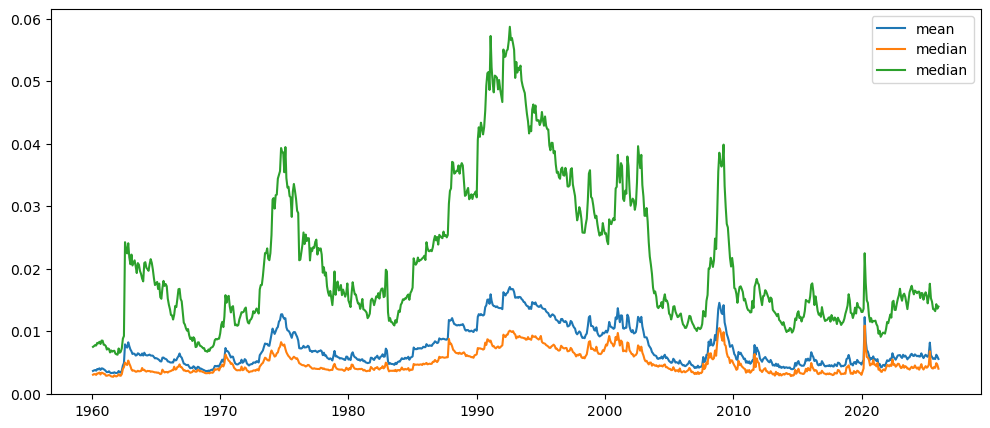

In [29]:
plt.figure(figsize=(12,5))

plt.plot(monthly['date'], monthly['mean'], label='mean')
plt.plot(monthly['date'], monthly['median'], label='median')
plt.plot(monthly['date'], monthly['p95'], label='median')

plt.legend()

plt.show()

In [30]:
def q95(x):
    return x.quantile(0.95)
    
monthly = (
    tcost.groupby('yyyymm')[cols]
      .agg(['mean', 'median', q95])
)
monthly.columns = [f'{c}_{stat}' for c, stat in monthly.columns]
monthly = monthly.reset_index()
monthly['date'] = pd.to_datetime(monthly['yyyymm'].astype(str), format='%Y%m')+MonthEnd(0)
monthly

,yyyymm,gibbs_mean,gibbs_median,gibbs_q95,hl_mean,hl_median,hl_q95,chl_mean,chl_median,chl_q95,vov_mean,vov_median,vov_q95,date
0,196001,0.003420,0.002700,0.007645,0.001958,0.001730,0.004660,0.004064,0.003657,0.007541,0.004519,0.003744,0.009693,1960-01-31
1,196002,0.003434,0.002705,0.007829,0.001846,0.001552,0.004320,0.003983,0.003560,0.007730,0.004775,0.004010,0.010265,1960-02-29
2,196003,0.003431,0.002705,0.007803,0.001827,0.001466,0.004558,0.004121,0.003643,0.008158,0.004933,0.004124,0.010888,1960-03-31
3,196004,0.003431,0.002705,0.007777,0.001750,0.001502,0.004213,0.003883,0.003413,0.007824,0.004808,0.003956,0.010913,1960-04-30
4,196005,0.003431,0.002707,0.007770,0.002010,0.001571,0.005048,0.004404,0.003852,0.009022,0.005152,0.004239,0.011223,1960-05-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,202508,0.005071,0.003786,0.012396,0.005941,0.004532,0.014457,0.007148,0.005672,0.016961,0.004252,0.002437,0.013566,2025-08-31
788,202509,0.005074,0.003795,0.012362,0.006147,0.004733,0.014697,0.007206,0.005543,0.017646,0.003711,0.001978,0.011776,2025-09-30
789,202510,0.005076,0.003801,0.012312,0.006256,0.004875,0.014899,0.007382,0.005769,0.017503,NaN,NaN,NaN,2025-10-31
790,202511,0.005065,0.003798,0.012280,0.006667,0.005495,0.015116,0.007626,0.006092,0.017473,0.004323,0.002328,0.014346,2025-11-30


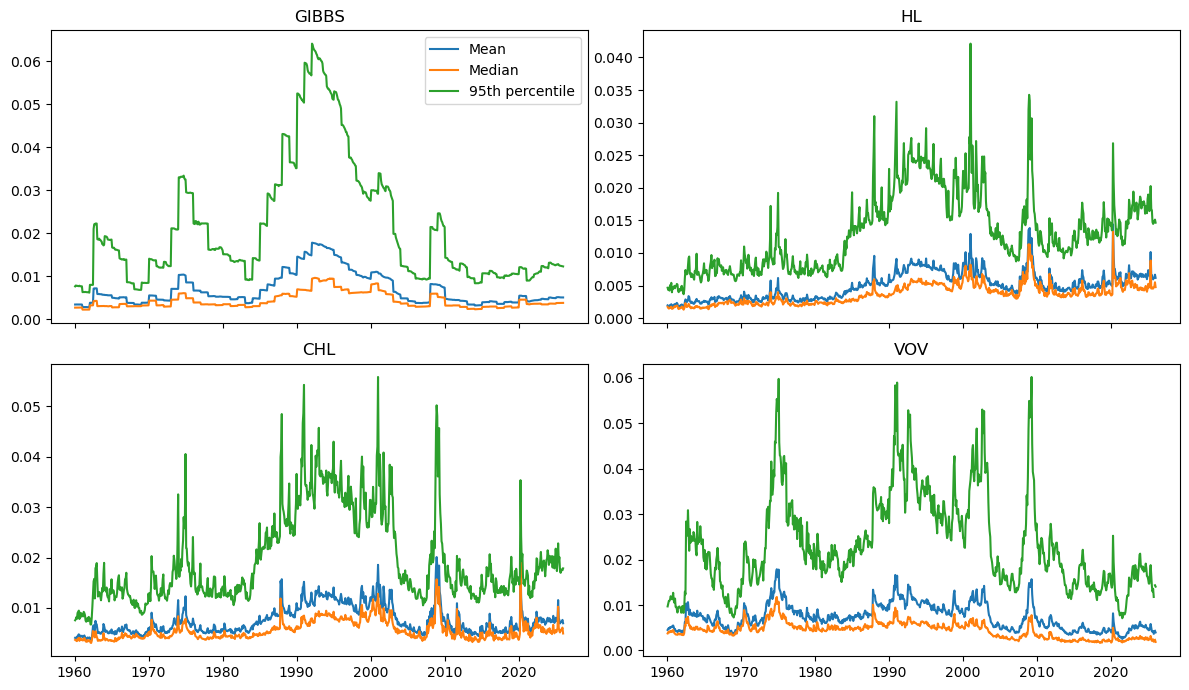

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()   # or axes.flatten()

for i, v in enumerate(cols):
    axes[i].plot(monthly['date'], monthly[f'{v}_mean'], label='Mean')
    axes[i].plot(monthly['date'], monthly[f'{v}_median'], label='Median')
    axes[i].plot(monthly['date'], monthly[f'{v}_q95'], label='95th percentile')

    axes[i].set_title(v.upper())
    if i == 0:
        axes[i].legend()

# Hide the unused 4th subplot
#axes[3].set_visible(False)

plt.tight_layout()
plt.show()